<a href="https://colab.research.google.com/github/mallurivikas/AI4IND/blob/main/federrated_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import copy
import random

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [ ]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

In [ ]:
print("Training Images :", len(train_dataset))
print("Testing Images  :", len(test_dataset))

Training Images : 60000
Testing Images  : 10000


In [ ]:
image, label = train_dataset[0]

print("Image Shape :", image.shape)
print("Label :", label)

Image Shape : torch.Size([1, 28, 28])
Label : 5


In [ ]:
class SimpleNN(nn.Module):

    def __init__(self):
        super(SimpleNN, self).__init__()

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(28 * 28, 128)

        self.relu = nn.ReLU()

        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        x = self.flatten(x)

        x = self.fc1(x)

        x = self.relu(x)

        x = self.fc2(x)

        return x

In [ ]:
global_model = SimpleNN().to(device)

print(global_model)

SimpleNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [ ]:
client_sizes = [30000, 18000, 12000]

In [ ]:
indices = list(range(len(train_dataset)))

random.shuffle(indices)

In [ ]:
client_indices = []

start = 0

for size in client_sizes:

    client_indices.append(indices[start:start + size])

    start += size

In [ ]:
client_datasets = [
    Subset(train_dataset, idxs)
    for idxs in client_indices
]

In [ ]:
client_loaders = [
    DataLoader(dataset,
               batch_size=32,
               shuffle=True)
    for dataset in client_datasets
]

In [ ]:
for i, dataset in enumerate(client_datasets):

    print(f"Client {i+1}: {len(dataset)} images")

Client 1: 30000 images
Client 2: 18000 images
Client 3: 12000 images


In [ ]:
def evaluate(model, test_loader, device):

    model.eval()

    loss_fn = nn.CrossEntropyLoss()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = loss_fn(outputs, labels)

            total_loss += loss.item()

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()

            total += labels.size(0)

    accuracy = 100 * correct / total
    avg_loss = total_loss / len(test_loader)

    return avg_loss, accuracy

In [ ]:
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [ ]:
global_accuracy_history = []
global_loss_history = []

In [ ]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim

class Client:

    def __init__(self, client_id, dataset, global_model, device):

        self.client_id = client_id

        self.device = device

        self.dataset = dataset

        self.loader = DataLoader(
            dataset,
            batch_size=32,
            shuffle=True
        )

        self.model = copy.deepcopy(global_model)

        self.loss_fn = nn.CrossEntropyLoss()

        self.optimizer = optim.SGD(
            self.model.parameters(),
            lr=0.01
        )
    def train(self, epochs=1):

      self.model.train()

      for epoch in range(epochs):

          total_loss = 0

          correct = 0

          total = 0

          for images, labels in self.loader:

              images = images.to(self.device)

              labels = labels.to(self.device)

              self.optimizer.zero_grad()

              outputs = self.model(images)

              loss = self.loss_fn(outputs, labels)

              loss.backward()

              self.optimizer.step()

              total_loss += loss.item()

              predictions = outputs.argmax(dim=1)

              correct += (predictions == labels).sum().item()

              total += labels.size(0)

          accuracy = 100 * correct / total

          print(
              f"Client {self.client_id} "
              f"| Epoch {epoch+1} "
              f"| Loss {total_loss:.2f} "
              f"| Accuracy {accuracy:.2f}%"
          )

    def get_weights(self):
        return self.model.state_dict()

class Server:

    def __init__(self, global_model):
        self.global_model = global_model

    def aggregate(self, clients):

        # Total number of samples across all clients
        total_samples = sum(len(client.dataset) for client in clients)

        # Copy the structure of the global model
        global_weights = copy.deepcopy(self.global_model.state_dict())

        # Iterate through every parameter (layer)
        for key in global_weights.keys():

            # Initialize this parameter with zeros
            global_weights[key] = torch.zeros_like(global_weights[key])

            # Add each client's weighted contribution
            for client in clients:

                client_weight = len(client.dataset) / total_samples

                global_weights[key] += (
                    client.get_weights()[key] * client_weight
                )

        # Update the global model with averaged weights
        self.global_model.load_state_dict(global_weights)

    def broadcast(self, clients):

        # Send the updated global model to every client
        for client in clients:
            client.model.load_state_dict(
                self.global_model.state_dict()
            )


# --------------------------------------------
# Create Clients
# --------------------------------------------

clients = [
    Client(1, client_datasets[0], global_model, device),
    Client(2, client_datasets[1], global_model, device),
    Client(3, client_datasets[2], global_model, device),
]

# Create Server
server = Server(global_model)

# --------------------------------------------
# Local Training
# --------------------------------------------
NUM_ROUNDS = 10

for round_num in range(NUM_ROUNDS):

    print("=" * 60)
    print(f"COMMUNICATION ROUND {round_num + 1}")
    print("=" * 60)

    # ----------------------------
    # Local Training
    # ----------------------------

    print("\nLocal Training...\n")

    for client in clients:
        client.train(epochs=1)

    # ----------------------------
    # Aggregate
    # ----------------------------

    print("\nAggregating Models...\n")

    server.aggregate(clients)

    print("✅ Global Model Updated!")

    loss, accuracy = evaluate(
        server.global_model,
        test_loader,
        device
    )

    global_loss_history.append(loss)
    global_accuracy_history.append(accuracy)

    print(f"\n🌍 Global Test Loss     : {loss:.4f}")
    print(f"🌍 Global Test Accuracy : {accuracy:.2f}%")

    server.broadcast(clients)

    print("✅ Updated Global Model Broadcasted!\n")

COMMUNICATION ROUND 1

Local Training...

Client 1 | Epoch 1 | Loss 1168.60 | Accuracy 72.64%
Client 2 | Epoch 1 | Loss 891.18 | Accuracy 65.47%
Client 3 | Epoch 1 | Loss 691.36 | Accuracy 58.76%

Aggregating Models...

✅ Global Model Updated!

🌍 Global Test Loss     : 0.7621
🌍 Global Test Accuracy : 84.34%
✅ Updated Global Model Broadcasted!

COMMUNICATION ROUND 2

Local Training...

Client 1 | Epoch 1 | Loss 530.83 | Accuracy 86.61%
Client 2 | Epoch 1 | Loss 348.62 | Accuracy 85.58%
Client 3 | Epoch 1 | Loss 247.20 | Accuracy 84.93%

Aggregating Models...

✅ Global Model Updated!

🌍 Global Test Loss     : 0.4694
🌍 Global Test Accuracy : 88.48%
✅ Updated Global Model Broadcasted!

COMMUNICATION ROUND 3

Local Training...

Client 1 | Epoch 1 | Loss 405.94 | Accuracy 88.64%
Client 2 | Epoch 1 | Loss 253.83 | Accuracy 88.06%
Client 3 | Epoch 1 | Loss 174.24 | Accuracy 88.16%

Aggregating Models...

✅ Global Model Updated!

🌍 Global Test Loss     : 0.3875
🌍 Global Test Accuracy : 89.70%
✅

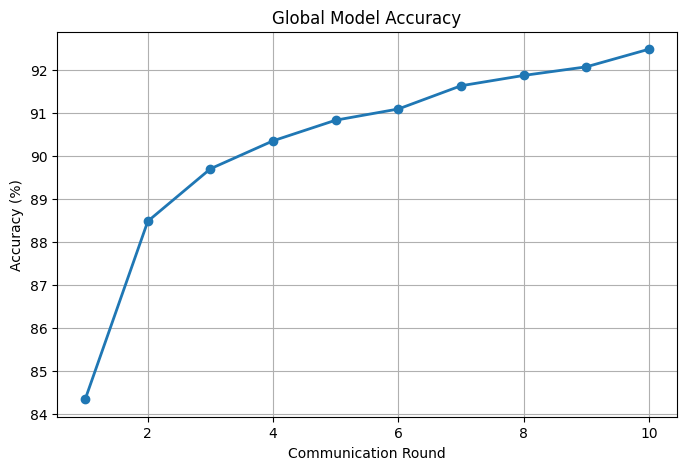

In [ ]:
import matplotlib.pyplot as plt

rounds = range(1, len(global_accuracy_history) + 1)

plt.figure(figsize=(8,5))

plt.plot(
    rounds,
    global_accuracy_history,
    marker='o',
    linewidth=2
)

plt.title("Global Model Accuracy")
plt.xlabel("Communication Round")
plt.ylabel("Accuracy (%)")
plt.grid(True)

plt.show()

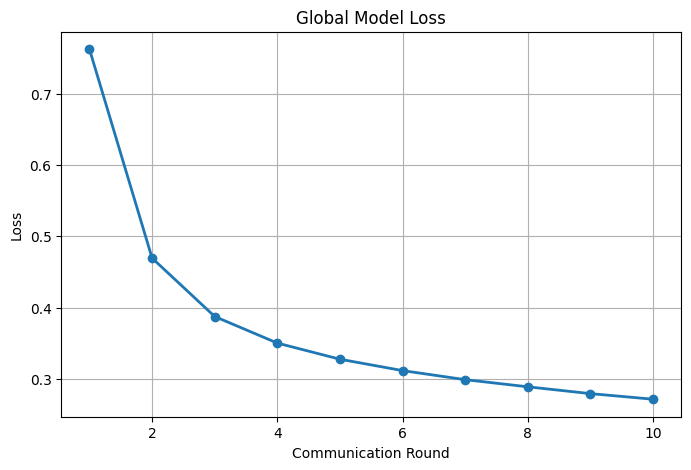

In [ ]:
rounds = range(1, len(global_loss_history) + 1)

plt.figure(figsize=(8,5))

plt.plot(
    rounds,
    global_loss_history,
    marker='o',
    linewidth=2
)

plt.title("Global Model Loss")
plt.xlabel("Communication Round")
plt.ylabel("Loss")
plt.grid(True)

plt.show()